<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Table of Contents:

- [Imports](#imports)
- [Raw Dataset](#raw-dataset)
- [Reduced Dataset](#reduced-dataset)
- [Miscellaneous](#miscellaneous)

</div>

##### IMPORTANT:
- This assumes that you have downloaded the raw dataset, [RADIOML 2018.01A from Deepsig](https://www.deepsig.ai/datasets/), and have it readily available inside the `../Datasets` folder
- THE RAW DATASET IS ~42GB

---

##### ORIENTATION:
- This demonstrates loading in the Deepsig raw dataset, showing its general contents and signal example, then creates a reduced dataframe that only has 1,000 samples per modulation type - Effectively reducing the raw dataset size down to ~1% - to expedite data exploration, feature engineering, and model training (Also because my computer isn't that strong).  

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Imports

- [Back to Table of Contents](#table-of-contents)

</div>

In [ ]:
import acquire as a
import os                       # Reduced dataset creation      
import numpy as np              # Reading of signal array data
import h5py                     # Reading of dataset
import matplotlib.pyplot as plt # Visualization of signal

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Raw Dataset

- [Back to Table of Contents](#table-of-contents)

</div>

In [1]:
# Define the file pathing of the raw dataset
raw_data_file_path = "../Datasets/GOLD_XYZ_OSC.0001_1024.hdf5"

# Define the file pathing of the modulation class ID translation
mod_class_file_path = "../Datasets/classes-fixed.txt"

In [ ]:
with h5py.File(raw_data_file_path, "r") as f:
    for key in f.keys():
        print(key, f[key].shape, f[key].dtype)

In [ ]:
# Read in the dataset and show the contents

In [45]:
mod_class_file = "../Datasets/classes-fixed.txt"
mod_class_dict = {}

with open(mod_class_file, 'r') as f:
    for line in f:
        if line.startswith('|'):
            line_val_list = line.split('|')
            if line_val_list[1].strip().isnumeric():
                try:
                    index = int(line_val_list[1].strip()) 
                    fixed_mod_class = str(line_val_list[3].strip().strip("'"))
                    mod_class_dict[index] = fixed_mod_class
                except TypeError:
                    continue

print(mod_class_dict)

{0: 'OOK', 1: '4ASK', 2: '8ASK', 3: 'BPSK', 4: 'QPSK', 5: '8PSK', 6: '16PSK', 7: '32PSK', 8: '16APSK', 9: '32APSK', 10: '64APSK', 11: '128APSK', 12: '16QAM', 13: '32QAM', 14: '64QAM', 15: '128QAM', 16: '256QAM', 17: 'AM-SSB-WC', 18: 'AM-SSB-SC', 19: 'AM-DSB-WC', 20: 'AM-DSB-SC', 21: 'FM', 22: 'GMSK', 23: 'OQPSK'}


Signal shape: (1024, 2)
Modulation Class OOK
SNR: -20


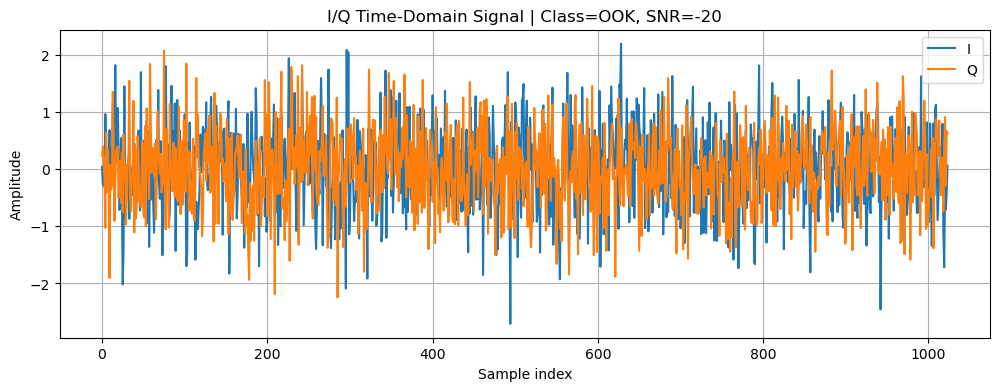

In [70]:
file_path = "../Datasets/GOLD_XYZ_OSC.0001_1024.hdf5"

idx = 0  # change this to view a different signal

with h5py.File(file_path, "r") as f:
    x = f["X"][idx]   # shape: (1024, 2)
    y = f["Y"][idx]   # shape: (24,)
    z = f["Z"][idx]   # shape: (1,)

I = x[:, 0]
Q = x[:, 1]

mod_class = np.argmax(y)
snr = z[0]

print("Signal shape:", x.shape)
print("Modulation Class", mod_class_dict[mod_class])
print("SNR:", snr)

plt.figure(figsize=(12, 4))
plt.plot(I, label="I")
plt.plot(Q, label="Q")
plt.xlabel("Sample index")
plt.ylabel("Amplitude")
plt.title(f"I/Q Time-Domain Signal | Class={mod_class_dict[mod_class]}, SNR={snr}")
plt.legend()
plt.grid(True)
plt.show()

In [80]:
file_path = "../Datasets/GOLD_XYZ_OSC.0001_1024.hdf5"

with h5py.File(file_path, "r") as f:
    Z = f["Z"][:].flatten()
    Y = f["Y"][:]

labels = np.argmax(Y, axis=1)

snr_indicies = np.where(Z == -20)[0]
print(np.argmax(Y[2039578]))
mod_indicies = [np.argmax(idx) for idx in Y[idx] if np.argmax(Y[idx]) == 0]

print("Number of SNR=0 examples:", len(snr_indicies))
print("Class distribution:")
print(snr_indicies)
print(mod_indicies)
print(np.unique(labels[snr_indicies], return_counts=True))

19
Number of SNR=0 examples: 98304
Class distribution:
[      0       1       2 ... 2453501 2453502 2453503]
[np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]
(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23]), array([4096, 4096, 4096, 4096, 4096, 4096, 4096, 4096, 4096, 4096, 4096,
       4096, 4096, 4096, 4096, 4096, 4096, 4096, 4096, 4096, 4096, 4096,
       4096, 4096]))


<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Reduced Dataset

- [Back to Table of Contents](#table-of-contents)

</div>

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Miscellaneous

- [Back to Table of Contents](#table-of-contents)

</div>